**Step 1 — Import Libraries & Load Data**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sent = pd.read_csv('/content/drive/MyDrive/Projects/csv_files/fear_greed_index.csv')
hist = pd.read_csv('/content/drive/MyDrive/Projects/csv_files/historical_data.csv')


**Step 2 — Clean & Prepare Sentiment Dataset**

In [25]:
sent.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [26]:
hist.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [27]:
sent['Date'] = pd.to_datetime(sent['date'])
sent['sentiment_flag'] = sent['classification'].map({'Fear':0, 'Greed':1})

**Step 3 — Clean & Prepare Trader Dataset**

In [28]:
#changing all the timestamp to datetime format
sent['timestamp'] = pd.to_datetime(sent['timestamp'])

# If 'date' column exists but may be string, convert:
sent['date'] = pd.to_datetime(sent['date'])

# Create binary sentiment columns
sent['sentiment_flag'] = sent['classification'].map({'Fear':0, 'Greed':1})


**Clean Trader Dataset**

In [29]:
# Convert timestamps to datetime format
hist['Timestamp IST'] = pd.to_datetime(hist['Timestamp IST'], format="%d-%m-%Y %H:%M")

# Extract date for merging
hist['date'] = hist['Timestamp IST'].dt.date
hist['date'] = pd.to_datetime(hist['date'])

**Create Additional Features**

In [30]:
hist['trade_volume'] = hist['Size USD']

In [31]:
hist['trade_volume'] = hist['Execution Price'] * hist['Size Tokens']

In [32]:
hist['risk_exposure'] = hist['Execution Price'] * hist['Size Tokens']

**Merge Trader Data with Sentiment**

In [33]:
df = hist.merge(sent[['date','sentiment_flag','value','classification']], on='date', how='left')

# **Graphical representation of the values**

Profitability in Fear vs Greed

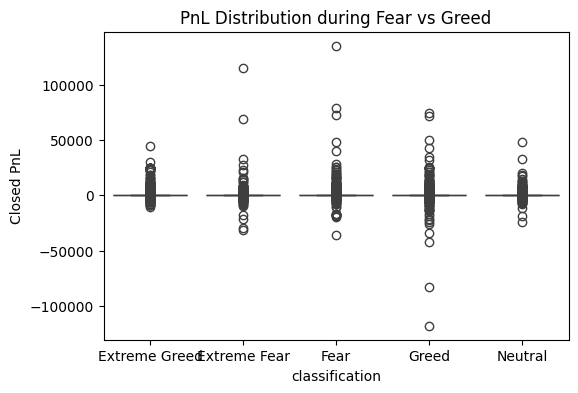

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['classification'], y=df['Closed PnL'])
plt.title("PnL Distribution during Fear vs Greed")
plt.savefig("/content/drive/MyDrive/Projects/csv_files/pnl_vs_sentiment.png")
plt.show()

Trading Volume Difference

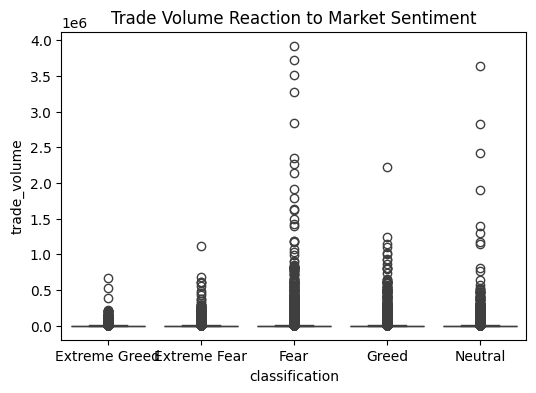

In [35]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['classification'], y=df['trade_volume'])
plt.title("Trade Volume Reaction to Market Sentiment")
plt.savefig("/content/drive/MyDrive/Projects/csv_files/volume_reaction.png")
plt.show()

Risk Exposure Difference

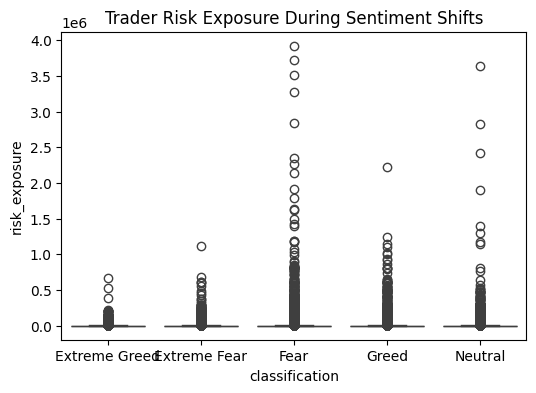

In [36]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['classification'], y=df['risk_exposure'])
plt.title("Trader Risk Exposure During Sentiment Shifts")
plt.savefig("/content/drive/MyDrive/Projects/csv_files/risk_analysis.png")
plt.show()

Sentiment Score vs Average PnL Per Day

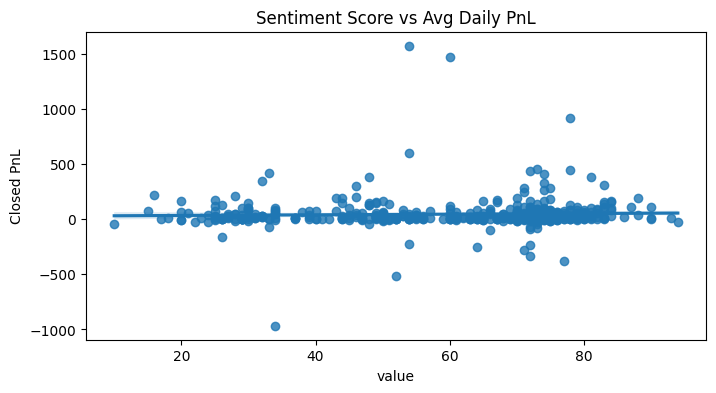

In [38]:
daily = df.groupby('date').agg({
    'Closed PnL':'mean',
    'value':'mean'
}).reset_index()

plt.figure(figsize=(8,4))
sns.regplot(data=daily, x='value', y='Closed PnL')
plt.title("Sentiment Score vs Avg Daily PnL")
plt.savefig("/content/drive/MyDrive/Projects/csv_files/sentiment_vs_pnl.png")
plt.show()
